# Real-world Data Wrangling

In [40]:
!python -m pip install kaggle==1.6.12

In [41]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

### **1.1.** Problem Statement
How do fluctuations in the 30-year fixed mortgage rate relate to typical home value trends (ZVHI) across U.S. metropolitan markets over time?

### **1.2.** Gather at least two datasets using two different data gathering methods

#### **Dataset 1**

Type: CSV File

Method: The data was gathered by downloading the Zillow Home Value Index (ZVHI) CSV file manually from the Zillow Research data page and loading it programmatically using Python's `pandas` library.

Dataset variables:

*   `RegionName`: The name of the region or Metropolitan Statistical Area (MSA) (e.g., "Los Angeles, CA").
*   `StateName`: The two-letter abbreviation of the state where the region is located (e.g., "CA").
*   `RegionID`: A unique numerical identifier assigned to each region by Zillow.
*   `SizeRank`: A rank representation based on the population size of the metropolitan area (where 0 is the most populous).
*  `RegionType`: The classification or scale of the geographic region (for example, country for national-level metrics, or msa for Metropolitan Statistical Area).
*   `2000-01-31` to `2026-05-31` (Monthly Date Columns): The Zillow Home Value Index (ZHVI) value representing the typical home value for that region in a given month.

In [42]:
import pandas as pd
from IPython.display import display

# Load the Zillow Home Value Index dataset programmatically
zillow_df = pd.read_csv('Zillow_HomeValueIndex.csv')

# Display the first few rows of the dataframe to verify it loaded correctly
zillow_df.head()


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
0,102001,0,United States,country,NaN,124226.850719,124445.405574,124716.445774,125297.773801,125966.812663,...,366338.323837,366583.636859,367024.612896,367710.944113,368513.889428,369279.951949,370005.007795,370503.068810,370583.649909,370320.231928
1,394913,1,"New York, NY",msa,NY,220241.022643,221176.922725,222121.490928,224035.551610,226017.627731,...,702535.550236,703949.305049,706306.806277,709680.532631,713132.753507,716225.158400,719831.723350,723655.272546,726086.278463,727625.487581
2,753899,2,"Los Angeles, CA",msa,CA,225669.811207,226509.589232,227628.165553,229853.756673,232287.855633,...,957302.987799,958379.278078,960840.171876,964218.923597,968252.041247,970828.794664,972083.425340,971743.362813,970091.338711,968608.414008
3,394463,3,"Chicago, IL",msa,IL,156798.618056,156943.767900,157220.208333,157907.923431,158735.161975,...,341428.373236,342790.550639,344123.864996,345705.325594,347475.565448,349131.015117,350915.816595,352352.255440,353373.098703,353998.242501
4,394514,4,"Dallas, TX",msa,TX,131332.841965,131391.338072,131458.585335,131633.219413,131863.469663,...,373414.212536,372748.386147,372389.688238,372118.383227,371894.357439,371448.263585,370856.387408,369771.000631,368421.163266,366823.210136


#### Dataset 2

Type: CSV File

Method: The data was gathered using the "Programmatic Downloading" method. The CSV file was retrieved directly from the Federal Reserve Economic Data (FRED) public database URL using Python's `pandas.read_csv()` function.

Dataset variables:
*   `observation_date`: The date of the weekly interest rate measurement (formatted as YYYY-MM-DD).
*   `MORTGAGE30US`: The average interest rate for a 30-year fixed-rate mortgage in the United States (expressed as a percentage, e.g., 7.33%).

In [43]:
import pandas as pd

# Define the programmatic download URL for FRED mortgage rate data
fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

# Load the dataset programmatically
mortgage_df = pd.read_csv(fred_url)

# Display the dataset shape and first few rows to verify loading
print(f"Dataset shape: {mortgage_df.shape}")
mortgage_df.head()


Dataset shape: (2894, 2)


,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


## 2. Assess data

### Quality Issue 1:

In [44]:
# Display a slice of the dataframe containing missing values (NaNs)
# We look at the first 5 rows with missing values and show metadata + some early date columns
zillow_df[zillow_df.isnull().any(axis=1)].iloc[:5, :12]

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30,2000-07-31
0,102001,0,United States,country,NaN,124226.850719,124445.405574,124716.445774,125297.773801,125966.812663,126684.112495,127443.873514
4,394514,4,"Dallas, TX",msa,TX,131332.841965,131391.338072,131458.585335,131633.219413,131863.469663,132096.530458,132340.891513
11,394976,11,"Phoenix, AZ",msa,AZ,144621.010629,144914.489697,145300.990046,146094.712435,146967.490977,147709.454054,148446.804078
33,394705,34,"Indianapolis, IN",msa,IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,395059,36,"San Jose, CA",msa,CA,375013.804973,376946.593470,379858.303986,387743.425193,396010.491678,405482.558846,413637.153041


In [45]:
# Programmatically calculate the total number of missing values in home value columns
total_nulls = zillow_df.iloc[:, 5:].isnull().sum().sum()
total_cells = zillow_df.shape[0] * zillow_df.iloc[:, 5:].shape[1]
pct_missing = (total_nulls / total_cells) * 100

print(f"Total missing index values: {total_nulls} out of {total_cells}")
print(f"Percentage of missing data: {pct_missing:.2f}%")


Total missing index values: 49266 out of 283715
Percentage of missing data: 17.36%


Issue and justification: The Zillow Home Value Index dataset contains a large number of missing values (49,266 NaNs, or 17.36% of the home price cells). This occurs because smaller or newer metropolitan statistical areas (MSAs) do not have complete historical data dating back to 2000.

Visual inspection using a subset filter allows us to see how these NaNs are distributed in the columns. Programmatic inspection counts the exact volume of missing values so we can make an informed decision on whether to drop incomplete regions or fill the gaps.

### Quality Issue 2:

In [46]:
# Visually inspect the formatting of the date columns
print("Zillow Date Column Header Examples (first 5 dates):")
print(list(zillow_df.columns[5:10]))

print("\nMortgage Date Column Values (first 5):")
print(mortgage_df['observation_date'].head())


Zillow Date Column Header Examples (first 5 dates):
['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31']

Mortgage Date Column Values (first 5):
0    1971-04-02
1    1971-04-09
2    1971-04-16
3    1971-04-23
4    1971-04-30
Name: observation_date, dtype: object


In [47]:
# Programmatically inspect the exact data types of the date variables
print(f"Mortgage 'observation_date' data type: {mortgage_df['observation_date'].dtype}")

Mortgage 'observation_date' data type: object


Issue and justification: The date columns in both datasets are represented as string objects instead of `datetime64`. For the Zillow dataset, the dates are stored as column headers. For the Mortgage dataset, the `observation_date` is a text column. 

Visual inspection shows the dates are structured as text. Programmatic inspection verifies that Pandas recognizes them as strings (`object`). We must convert these to datetime objects to perform chronological sorting, time-series plotting, and merging operations.

### Tidiness Issue 1:

Here are the three essential rules of data tidiness:

1. Each variable forms a column: Each unique variable in the dataset should be in its own column.
2. Each observation forms a row: Each individual data observation should have its own row.
3. Each type of observational unit forms a table: Different types of data (e.g., customers and products) should be in separate tables unless they are directly related.

In [48]:
# Inspecting the dataframe visually
zillow_df.iloc[:5, :10] # Selects the first 5 rows and the first 10 columns

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31
0,102001,0,United States,country,NaN,124226.850719,124445.405574,124716.445774,125297.773801,125966.812663
1,394913,1,"New York, NY",msa,NY,220241.022643,221176.922725,222121.490928,224035.551610,226017.627731
2,753899,2,"Los Angeles, CA",msa,CA,225669.811207,226509.589232,227628.165553,229853.756673,232287.855633
3,394463,3,"Chicago, IL",msa,IL,156798.618056,156943.767900,157220.208333,157907.923431,158735.161975
4,394514,4,"Dallas, TX",msa,TX,131332.841965,131391.338072,131458.585335,131633.219413,131863.469663


In [49]:
zillow_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
0,102001,0,United States,country,NaN,124226.850719,124445.405574,124716.445774,125297.773801,125966.812663,...,366338.323837,366583.636859,367024.612896,367710.944113,368513.889428,369279.951949,370005.007795,370503.068810,370583.649909,370320.231928
1,394913,1,"New York, NY",msa,NY,220241.022643,221176.922725,222121.490928,224035.551610,226017.627731,...,702535.550236,703949.305049,706306.806277,709680.532631,713132.753507,716225.158400,719831.723350,723655.272546,726086.278463,727625.487581
2,753899,2,"Los Angeles, CA",msa,CA,225669.811207,226509.589232,227628.165553,229853.756673,232287.855633,...,957302.987799,958379.278078,960840.171876,964218.923597,968252.041247,970828.794664,972083.425340,971743.362813,970091.338711,968608.414008
3,394463,3,"Chicago, IL",msa,IL,156798.618056,156943.767900,157220.208333,157907.923431,158735.161975,...,341428.373236,342790.550639,344123.864996,345705.325594,347475.565448,349131.015117,350915.816595,352352.255440,353373.098703,353998.242501
4,394514,4,"Dallas, TX",msa,TX,131332.841965,131391.338072,131458.585335,131633.219413,131863.469663,...,373414.212536,372748.386147,372389.688238,372118.383227,371894.357439,371448.263585,370856.387408,369771.000631,368421.163266,366823.210136


Observation: There are hundreds of monthly date columns.

In [50]:
# Inspecting the dataframe programmatically

# Check total number of columns and verify that column names are dates
print(f"Total columns in zillow_df: {zillow_df.shape[1]}")

print(f"Date column headers: {list(zillow_df.columns[5:10])}")

Total columns in zillow_df: 322
Date column headers: ['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31']


Issue and justification: Column headers are values, not variable names. This violates rule 1 (each variable is a column) and rule 2 (each observation is a row). Each row should represent one region on one date.

### Tidiness Issue 2: 

In [51]:
# Inspecting the dataframe visually
# Check the different region types in Zillow and the date frequency in mortgage_df
print("Zillow Region Types:")
display(zillow_df[['RegionName', 'RegionType']].drop_duplicates().head())

print("\nMortgage Weekly Observations:")
display(mortgage_df.head())


Zillow Region Types:


,RegionName,RegionType
0,United States,country
1,"New York, NY",msa
2,"Los Angeles, CA",msa
3,"Chicago, IL",msa
4,"Dallas, TX",msa



Mortgage Weekly Observations:


,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


We can see there's a mix of types: country and msa (metropolitan).

In [52]:
# Inspecting the dataframe programmatically
# Count region types in Zillow
print("RegionType counts in Zillow:")
print(zillow_df['RegionType'].value_counts())

# Check the frequency/gap between mortgage observation dates
mortgage_dates = pd.to_datetime(mortgage_df['observation_date'])

# diff() computes the difference between an element and a previous element in a series, and returns a series
date_diffs = mortgage_dates.diff().dt.days.value_counts()
print("\nMortgage observation interval (days between rows):")
print(date_diffs.head()) # date_diffs shows the day intervals on the left and frequency counts on the right




RegionType counts in Zillow:
RegionType
msa        894
country      1
Name: count, dtype: int64

Mortgage observation interval (days between rows):
observation_date
7.0    2807
8.0      42
6.0      41
5.0       2
9.0       1
Name: count, dtype: int64


There are 2 region types in Zillow, Metropolitan and Country. We can also see that the most common mortgage observation interval is 7 days.

Issue and justification: Rule 3 requires that each observational unit form a table and rule 2 requires that each observation form a row. There are 2 issues: 
1. The Zillow dataset mixes multiple observational units in a single table which violates rule 3.
2. The two datasets have mismatched observation frequencies as mortgage rates are recorded weekly and Zillow home values are recorded monthly.

To resolve these issues, I'll separate the national (country) row from the metropolitan (msa) records, and resample the weekly mortgage interest rates to monthly averages before merging.

## 3. Clean data

In [53]:
# Make copies of the datasets to ensure the raw dataframes 
# are not impacted
zillow_clean = zillow_df.copy()
mortgage_clean = mortgage_df.copy()

### **Quality Issue 1: Missing Values in the Zillow Home Value Index**

In [54]:
# Apply the cleaning strategy

# Drop regions with missing historical values
zillow_clean = zillow_clean.dropna()

In [55]:
# Validate the cleaning was successful

# Validate that no missing values remain in zillow_clean
print("Total missing values remaining:", zillow_clean.isnull().sum().sum())
print("Remaining regions:", zillow_clean.shape[0])


Total missing values remaining: 0
Remaining regions: 300


Justification: Regions with missing monthly data were dropped to ensure only reliable historical records from 2000 to 2026 are used.

### **Quality Issue 2: Incorrect Data Type for Mortgage Observation Date**

In [56]:
# Apply the cleaning strategy
mortgage_clean['observation_date'] = pd.to_datetime(mortgage_clean['observation_date'])

In [57]:
# Validate the cleaning was successful
mortgage_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2894 entries, 0 to 2893
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  2894 non-null   datetime64[ns]
 1   MORTGAGE30US      2894 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 45.3 KB


Justification: I used to_datetime() to convert the 'observation_date' column values into datetime64 as seen in the output of .info(). This is useful for joining housing data together or resampling observation frequencies.

### **Tidiness Issue 1: Date values are stored as column headers instead of column values**

In [58]:
# Apply the cleaning strategy

# Leave the columns in id_vars unchanged, collapse all the date columns into one column named Date
zillow_clean = pd.melt(
    zillow_clean,
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName'],
    var_name='Date',
    value_name='HomeValue'
)

# Convert the new date column to DateTime
zillow_clean["Date"] = pd.to_datetime(zillow_clean["Date"])

In [59]:
# Validate the cleaning was successful

# Check the shape
zillow_clean.shape

(95100, 7)

We have dramatically reduced the number of columns from over 300 to 7.

In [60]:
zillow_clean.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,HomeValue
0,394913,1,"New York, NY",msa,NY,2000-01-31,220241.022643
1,753899,2,"Los Angeles, CA",msa,CA,2000-01-31,225669.811207
2,394463,3,"Chicago, IL",msa,IL,2000-01-31,156798.618056
3,394692,5,"Houston, TX",msa,TX,2000-01-31,126188.710992
4,395209,6,"Washington, DC",msa,VA,2000-01-31,184336.237518


Date column now contains all dates.

Justification: I used the pd.melt() function to reshape the table so that all the individual date columns get turned into a single 'Date' column. This is essential for merging with mortgage data and cleans up the table significantly.

### **Tidiness Issue 2: Mixed observational units and mismatched observation frequencies**

In [61]:
# Apply the cleaning strategy

# Filter for msa region type only
mask = zillow_clean["RegionType"] == 'msa'
zillow_clean = zillow_clean[mask]

# Resample mortgage weekly rates to monthly
mortgage_clean = mortgage_clean.resample('MS', on='observation_date').mean() # Take the mean to collapse weekly rows into a single monthly value

In [ ]:
# resample() places 'observation_date' as the DataFrame index, reset_index undos that
mortgage_clean = mortgage_clean.reset_index()

In [63]:
zillow_clean.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,HomeValue
0,394913,1,"New York, NY",msa,NY,2000-01-31,220241.022643
1,753899,2,"Los Angeles, CA",msa,CA,2000-01-31,225669.811207
2,394463,3,"Chicago, IL",msa,IL,2000-01-31,156798.618056
3,394692,5,"Houston, TX",msa,TX,2000-01-31,126188.710992
4,395209,6,"Washington, DC",msa,VA,2000-01-31,184336.237518


In [64]:
mortgage_clean.head()

,observation_date,MORTGAGE30US
0,1971-04-01,7.3100
1,1971-05-01,7.4250
2,1971-06-01,7.5300
3,1971-07-01,7.6040
4,1971-08-01,7.6975


In [65]:
# Validate the cleaning was successful
zillow_clean['RegionType'].unique()

array(['msa'], dtype=object)

In [66]:
mortgage_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  666 non-null    datetime64[ns]
 1   MORTGAGE30US      666 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 10.5 KB


We can see region type is filtered to msa only and mortgage df was reduced from thousands of weekly rows.

Justification: Filtering for msa ensures we focus on metropolitan markets as stated in the research question. Aggregating weekly mortgage rates into monthly averages helps align it with the monthly housing data.

### **Remove unnecessary variables and combine datasets**

In [67]:
# Remove unnecessary variables and combine datasets

# We don't need RegionType anymore because all rows are 'msa'. RegionName is better than RegionID. We need at least 4 variables in the final dataset: Date, RegionName, HomeValue, MORTGAGE30US
zillow_clean.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,HomeValue
0,394913,1,"New York, NY",msa,NY,2000-01-31,220241.022643
1,753899,2,"Los Angeles, CA",msa,CA,2000-01-31,225669.811207
2,394463,3,"Chicago, IL",msa,IL,2000-01-31,156798.618056
3,394692,5,"Houston, TX",msa,TX,2000-01-31,126188.710992
4,395209,6,"Washington, DC",msa,VA,2000-01-31,184336.237518


In [68]:
# Drop the fluff
zillow_clean = zillow_clean.drop(columns=['RegionID', 'SizeRank', 'RegionType', 'StateName'])

In [69]:
# Before combining, the Zillow dates are at the end of the month and the Mortgage dates are at the start of the month. Both date columns should be converted to month periods
zillow_clean["Date"] = zillow_clean["Date"].dt.strftime('%Y-%m')
mortgage_clean["observation_date"] = mortgage_clean["observation_date"].dt.strftime('%Y-%m')

zillow_clean.head()

,RegionName,Date,HomeValue
0,"New York, NY",2000-01,220241.022643
1,"Los Angeles, CA",2000-01,225669.811207
2,"Chicago, IL",2000-01,156798.618056
3,"Houston, TX",2000-01,126188.710992
4,"Washington, DC",2000-01,184336.237518


In [74]:
merged = zillow_clean.merge(mortgage_clean, left_on="Date", right_on="observation_date")
merged = merged.drop(columns=['observation_date']) # Drop redundant column
merged.head()

,RegionName,Date,HomeValue,MORTGAGE30US
0,"New York, NY",2000-01,220241.022643,8.21
1,"Los Angeles, CA",2000-01,225669.811207,8.21
2,"Chicago, IL",2000-01,156798.618056,8.21
3,"Houston, TX",2000-01,126188.710992,8.21
4,"Washington, DC",2000-01,184336.237518,8.21


## 4. Update your data store

In [75]:
# saving data

# raw copy of mortgage_df saved locally
mortgage_df.to_csv('raw_mortgage_rates.csv', index=False)

# save combined data
merged.to_csv('cleaned_housing_mortgage_data.csv', index=False)

## 5. Answer the research question

### **5.1:** Define and answer the research question 

*Research question:* "How do fluctuations in the 30-year fixed mortgage rate relate to typical home value trends (ZHVI) across U.S. metropolitan markets over time?"

In [76]:
import matplotlib.pyplot as plt

In [78]:
merged.head()

,RegionName,Date,HomeValue,MORTGAGE30US
0,"New York, NY",2000-01,220241.022643,8.21
1,"Los Angeles, CA",2000-01,225669.811207,8.21
2,"Chicago, IL",2000-01,156798.618056,8.21
3,"Houston, TX",2000-01,126188.710992,8.21
4,"Washington, DC",2000-01,184336.237518,8.21


<Axes: title={'center': '30-Year Fixed Mortgage Rate Over Time'}, xlabel='Date', ylabel='Interest Rate (%)'>

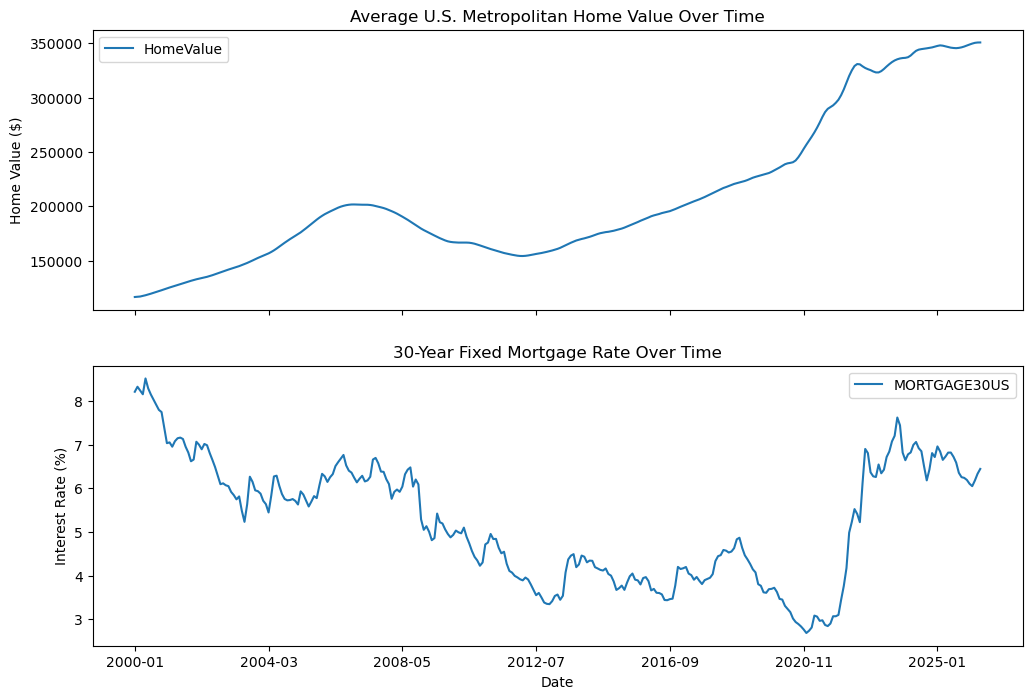

In [87]:
#Visual 1 - Macro Trends Over Time

# Create a figure with 2 subplots stacked verticially

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.set_title("Average U.S. Metropolitan Home Value Over Time")
ax2.set_title("30-Year Fixed Mortgage Rate Over Time")

# Plot the 1st column: Average Home Value
monthly_avg = merged.groupby('Date')[['HomeValue', 'MORTGAGE30US']].mean().reset_index()
monthly_avg.plot(x='Date', y='HomeValue', kind='line', ax=ax1, ylabel="Home Value ($)")

# Plot the 2nd column: Mortgage Rate
monthly_avg.plot(x = 'Date', y = 'MORTGAGE30US', ax=ax2, ylabel="Interest Rate (%)")

*Answer to research question:* The 30-year mortgage rate steadily decreased from 2000 until it hit a rock bottom in 2020 before suddenly spiking up. At the same time, home value rates steadily increased despite the short drop in 2008. There appears to be no correlation, as this goes against the idea that higher mortgage rates should lead to lower home prices.

<Axes: xlabel='MORTGAGE30US', ylabel='HomeValue'>

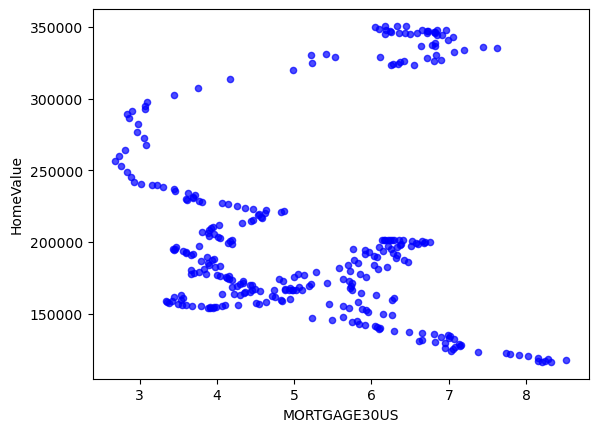

In [ ]:
#Visual 2 - Direct Correlation Check

# We will use a scatterplot to show that there is no correlation between MORTGAGE30US and HomeValue
monthly_avg.plot.scatter(x='MORTGAGE30US', y='HomeValue', color='blue', alpha=0.7)

*Answer to research question:* Looking at the plot, the data points to a dispersed cloud instead of a linear correlation upward or downward. This confirms there is no direct correlation between the raw mortgage rate and typical home values. Long-term home prices are heavily influenced by other sources such as inflation, wages, and housing shortages rather than tied directly to mortgages.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* I would compare different regions like Austin, Phoenix, and Tampa against high-cost costal metros like New York and San Francisco and see if they reacted differently to rate spikes. I would also be interested in analyzing how supply shortages affect home prices by analyzing housing inventory or construction permit data.